# Lung Cancer Detection from Chest CT Scans

**A transfer-learning image classifier that distinguishes lung cancer subtypes from chest CT slices.**

**Authors:** Azizbek Oqbutayev · Nozima Sotiboldiyeva
**Date:** 2026-06-16
**Tooling:** Python · PyTorch · scikit-learn · ONNX, built and documented with Claude Code (Opus 4.8)

---

This notebook documents the **entire** pipeline, step by step:

1. Background — and a myth-busting note about the "MIT lung cancer dataset"
2. Environment & reproducibility
3. Loading the data and normalizing class labels
4. Exploratory data analysis (EDA)
5. Preprocessing & data augmentation
6. Model architecture (transfer learning with MobileNetV2)
7. Training
8. Evaluation (accuracy, per-class metrics, confusion matrix, ROC/AUC, clinical sensitivity/specificity)
9. Explainability with Grad-CAM
10. Exporting the model to ONNX for an in-browser demo
11. Results summary, limitations & references

Every figure produced here is also saved into `../website/assets/` so the companion
website can render the same results visually.

## 1. Background — and the "MIT dataset" myth

This project started from a research note investigating a claim about a *"free lung cancer
dataset by MIT."* The finding was clear:

> **There is no lung cancer detection dataset created by MIT the institution.** The phrase
> almost always comes from confusing **MIT the university** with the **MIT License** — a
> permissive open-source license attached to countless community datasets and repos on
> Kaggle, Hugging Face and GitHub. (MIT's actual medical-data lab maintains the MIMIC ICU /
> chest-X-ray collections via PhysioNet — credentialed-access data, *not* lung cancer sets.)

The genuinely authoritative free lung-cancer datasets come from the **NIH/NCI** and **TCIA**
(LIDC-IDRI, LUNA16, NLST, NSCLC-Radiomics) plus academic sets like **LC25000**.

The literal "first dataset" in that note is **LIDC-IDRI** — ~125 GB of 3-D CT volumes
requiring the TCIA downloader, DICOM handling and 3-D CNNs on a GPU. That is impractical to
download/train here and impossible to embed in a lightweight web demo. So we use a smaller,
fully imaging-based, citable set instead:

**Dataset used: the Chest CT-Scan images set** (originally Kaggle / `mohamedhanyyy`, cited in
the source note's §B), mirrored on Hugging Face as `dorsar/lung-cancer`. Real chest-CT slices,
4 classes, pre-split into train/valid/test. Its license is — fittingly — **MIT**, which is a
live, real-world example of exactly the License-vs-institution confusion above.

## 2. Environment & reproducibility

We fix random seeds for reproducibility and select the Apple-Silicon **MPS** GPU backend if
available (this notebook was developed on a MacBook Air M4), otherwise CPU.

In [1]:
import os, random, json, time, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("PyTorch       :", torch.__version__)
print("Torchvision   :", torchvision.__version__)
print("Compute device:", DEVICE)

PyTorch       : 2.12.0
Torchvision   : 0.27.0
Compute device: mps


### Project paths

The notebook lives in `notebooks/`. We resolve the project root robustly and create the
output folders used by the website.

In [2]:
# Resolve project root whether the notebook runs from notebooks/ or the project root.
CANDIDATES = [
    Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent,
    Path("/Users/abdulhamidnuriddinov/Documents/Projects/Video Editing with Claude/lung-cancer-detection"),
]
ROOT = next((p for p in CANDIDATES if (p / "data" / "chest-ct" / "Data").exists()), Path.cwd().parent)

DATA_DIR   = ROOT / "data" / "chest-ct" / "Data"
MODELS_DIR = ROOT / "models"
WEB_DIR    = ROOT / "website"
ASSETS_DIR = WEB_DIR / "assets"
for d in (MODELS_DIR, ASSETS_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f"Dataset not found at {DATA_DIR}"
print("Project root:", ROOT)
print("Data dir    :", DATA_DIR)

def savefig(name, **kw):
    # Save the current matplotlib figure into the website assets folder.
    plt.savefig(ASSETS_DIR / name, dpi=110, bbox_inches="tight", **kw)

Project root: /Users/abdulhamidnuriddinov/Documents/Projects/Video Editing with Claude/lung-cancer-detection
Data dir    : /Users/abdulhamidnuriddinov/Documents/Projects/Video Editing with Claude/lung-cancer-detection/data/chest-ct/Data


## 3. Loading the data & normalizing class labels

The dataset has four classes. In the **train/valid** splits the class folders carry extra
TNM-staging text (e.g. `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib`), while the **test** split
uses clean names. We normalize every folder to one of four canonical labels.

In [3]:
CLASSES = ["adenocarcinoma", "large.cell.carcinoma", "normal", "squamous.cell.carcinoma"]
DISPLAY = {
    "adenocarcinoma":          "Adenocarcinoma",
    "large.cell.carcinoma":    "Large cell carcinoma",
    "normal":                  "Normal",
    "squamous.cell.carcinoma": "Squamous cell carcinoma",
}
CANCER_CLASSES = ["adenocarcinoma", "large.cell.carcinoma", "squamous.cell.carcinoma"]

def folder_to_class(name):
    n = name.lower()
    if n.startswith("adenocarcinoma"):          return "adenocarcinoma"
    if n.startswith("large"):                   return "large.cell.carcinoma"
    if n.startswith("squamous"):                return "squamous.cell.carcinoma"
    if n.startswith("normal"):                  return "normal"
    raise ValueError(f"Unrecognized class folder: {name}")

IMG_EXT = (".png", ".jpg", ".jpeg")

def scan_split(split):
    # Return list of (image_path, class_index) for a split.
    split_dir = DATA_DIR / split
    samples = []
    for sub in sorted(os.listdir(split_dir)):
        p = split_dir / sub
        if not p.is_dir():
            continue
        label = folder_to_class(sub)
        for f in sorted(os.listdir(p)):
            if f.lower().endswith(IMG_EXT):
                samples.append((str(p / f), CLASSES.index(label)))
    return samples

train_samples = scan_split("train")
valid_samples = scan_split("valid")
test_samples  = scan_split("test")
print(f"train={len(train_samples)}  valid={len(valid_samples)}  test={len(test_samples)}")

train=400  valid=72  test=295


In [4]:
# Build a tidy per-split / per-class count table.
def counts(samples):
    c = pd.Series([CLASSES[i] for _, i in samples]).value_counts()
    return c.reindex(CLASSES, fill_value=0)

count_df = pd.DataFrame({
    "train": counts(train_samples),
    "valid": counts(valid_samples),
    "test":  counts(test_samples),
})
count_df.index = [DISPLAY[c] for c in count_df.index]
count_df["total"] = count_df.sum(axis=1)
count_df.loc["TOTAL"] = count_df.sum()
count_df

,train,valid,test,total
Adenocarcinoma,100,23,100,223
Large cell carcinoma,100,21,51,172
Normal,100,13,54,167
Squamous cell carcinoma,100,15,90,205
TOTAL,400,72,295,767


## 4. Exploratory data analysis

### 4.1 Class distribution

The training set is balanced (100 images per class); the test set reflects a more realistic,
imbalanced distribution. We keep that in mind when reading the metrics later.

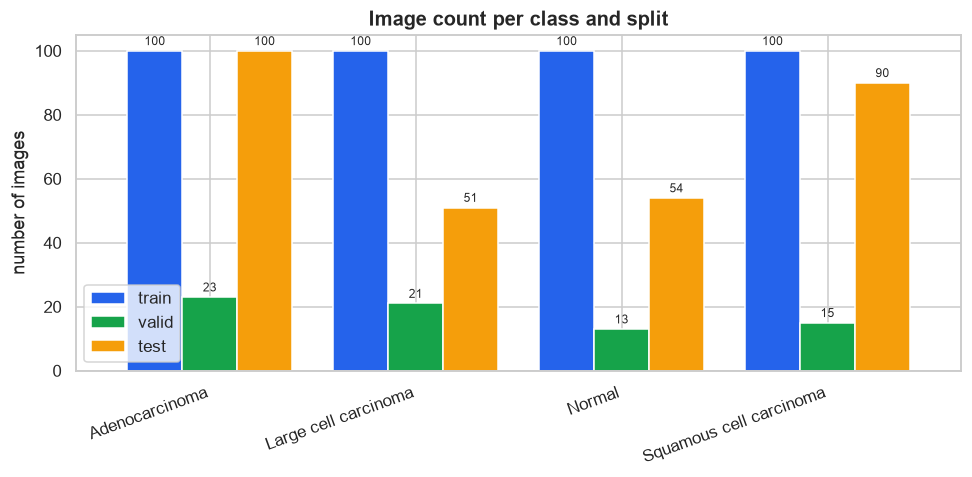

In [5]:
plot_df = count_df.drop(index="TOTAL").drop(columns="total")
ax = plot_df.plot(kind="bar", figsize=(9, 4.5), width=0.8,
                  color=["#2563eb", "#16a34a", "#f59e0b"])
ax.set_title("Image count per class and split", fontsize=13, weight="bold")
ax.set_ylabel("number of images"); ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
for c in ax.containers:
    ax.bar_label(c, fontsize=8, padding=2)
plt.tight_layout(); savefig("class_distribution.png"); plt.show()

### 4.2 Sample images

A quick visual sanity check — one representative slice from each class.

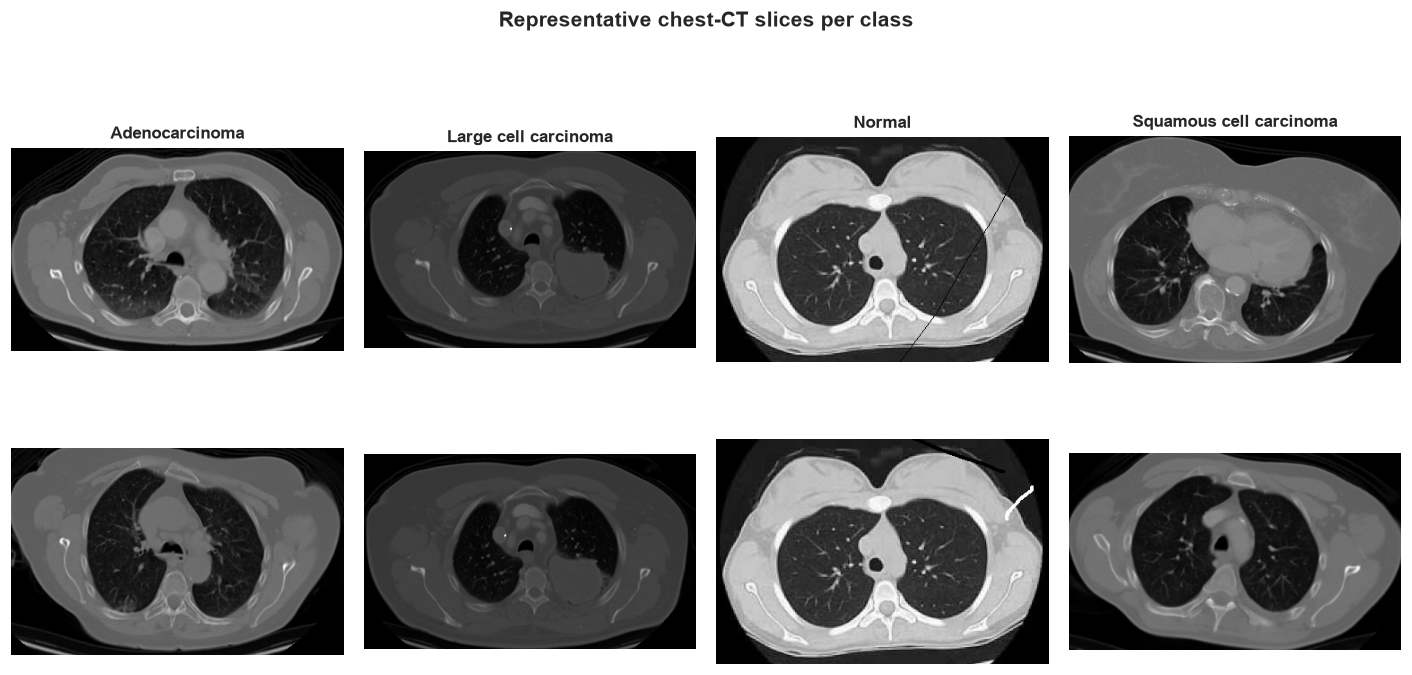

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for col, cls in enumerate(CLASSES):
    paths = [p for p, i in train_samples if i == CLASSES.index(cls)][:2]
    for row in range(2):
        ax = axes[row, col]
        img = Image.open(paths[row]).convert("RGB")
        ax.imshow(img); ax.axis("off")
        if row == 0:
            ax.set_title(DISPLAY[cls], fontsize=11, weight="bold")
fig.suptitle("Representative chest-CT slices per class", fontsize=14, weight="bold")
plt.tight_layout(); savefig("sample_images.png"); plt.show()

## 5. Preprocessing & data augmentation

Images are resized to **224×224** (the input size MobileNetV2 expects) and normalized with the
standard ImageNet mean/std, because we use ImageNet-pretrained weights. The **training** set
gets light augmentation (horizontal flip, small rotation, mild color jitter) to fight
overfitting on a small dataset; validation/test get only deterministic resize + normalize.

> We deliberately use a plain `Resize((224, 224))` (no center-crop) so the exact same
> preprocessing can be reproduced in JavaScript for the in-browser demo.

In [7]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class CTScanDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

BATCH = 32
train_ds = CTScanDataset(train_samples, train_tf)
valid_ds = CTScanDataset(valid_samples, eval_tf)
test_ds  = CTScanDataset(test_samples,  eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)
print("batches:", len(train_loader), len(valid_loader), len(test_loader))

batches: 13 3 10


## 6. Model — transfer learning with MobileNetV2

Training a deep CNN from scratch on a few hundred images would overfit badly. Instead we use
**transfer learning**: take **MobileNetV2** pretrained on ImageNet, **freeze** its convolutional
feature extractor, and train only a fresh classification head for our four classes.

Why MobileNetV2?
- Strong ImageNet features that transfer well to medical images.
- Small and fast — ~3.5M parameters — so it **exports cleanly to ONNX and runs in a browser**.

In [8]:
def build_model(num_classes=len(CLASSES)):
    weights = MobileNet_V2_Weights.IMAGENET1K_V1
    model = mobilenet_v2(weights=weights)
    for p in model.features.parameters():      # freeze the backbone
        p.requires_grad = False
    in_feats = model.classifier[1].in_features
    model.classifier = nn.Sequential(          # new trainable head
        nn.Dropout(0.3),
        nn.Linear(in_feats, num_classes),
    )
    return model

model = build_model().to(DEVICE)
n_total  = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {n_total:,}")
print(f"Trainable parameters: {n_train:,}  (classification head only)")

Total parameters    : 2,228,996
Trainable parameters: 5,124  (classification head only)


## 7. Training

We train the head with the Adam optimizer and cross-entropy loss, reducing the learning rate
when validation loss plateaus, and keep the weights from the **best validation accuracy** epoch.

In [9]:
EPOCHS = 30
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

def run_epoch(loader, train=False):
    model.train() if train else model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    torch.set_grad_enabled(train)
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if train:
            optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        if train:
            loss.backward(); optimizer.step()
        loss_sum += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)
    return loss_sum / total, correct / total

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, best_state = 0.0, None
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(valid_loader, train=False)
    scheduler.step(va_loss)
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
    if va_acc >= best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f"epoch {epoch:02d}/{EPOCHS}  "
          f"train_loss={tr_loss:.3f} acc={tr_acc:.3f}  |  val_loss={va_loss:.3f} acc={va_acc:.3f}")
print(f"\nTrained in {time.time()-t0:.1f}s. Best val accuracy = {best_val_acc:.3f}")

model.load_state_dict(best_state)                 # restore best weights
torch.save(best_state, MODELS_DIR / "best_model.pt")
print("Saved best weights ->", MODELS_DIR / "best_model.pt")

epoch 01/30  train_loss=1.295 acc=0.385  |  val_loss=1.314 acc=0.361


epoch 02/30  train_loss=1.070 acc=0.500  |  val_loss=1.219 acc=0.431


epoch 03/30  train_loss=0.903 acc=0.630  |  val_loss=1.114 acc=0.458


epoch 04/30  train_loss=0.867 acc=0.615  |  val_loss=0.991 acc=0.569


epoch 05/30  train_loss=0.803 acc=0.660  |  val_loss=0.899 acc=0.583


...

epoch 26/30  train_loss=0.543 acc=0.805  |  val_loss=0.878 acc=0.681


epoch 27/30  train_loss=0.567 acc=0.760  |  val_loss=0.858 acc=0.694


epoch 28/30  train_loss=0.520 acc=0.818  |  val_loss=0.861 acc=0.681


epoch 29/30  train_loss=0.525 acc=0.812  |  val_loss=0.860 acc=0.694


epoch 30/30  train_loss=0.541 acc=0.805  |  val_loss=0.857 acc=0.694

Trained in 69.9s. Best val accuracy = 0.694
Saved best weights -> /Users/abdulhamidnuriddinov/Documents/Projects/Video Editing with Claude/lung-cancer-detection/models/best_model.pt


### Training curves

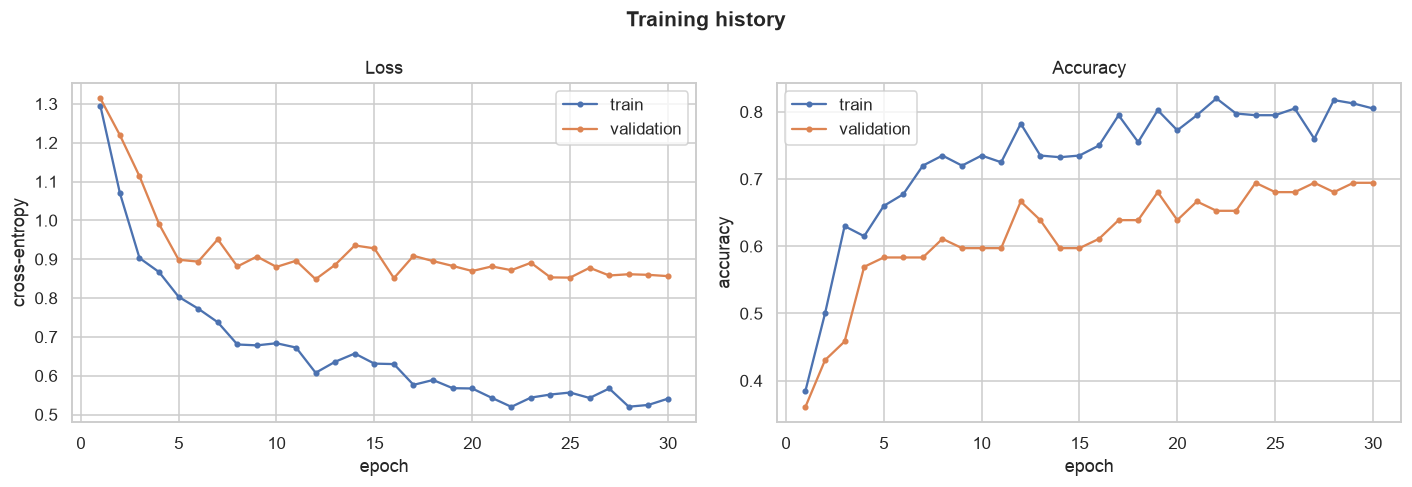

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
ep = range(1, EPOCHS + 1)
a1.plot(ep, history["train_loss"], label="train", marker="o", ms=3)
a1.plot(ep, history["val_loss"],   label="validation", marker="o", ms=3)
a1.set_title("Loss"); a1.set_xlabel("epoch"); a1.set_ylabel("cross-entropy"); a1.legend()
a2.plot(ep, history["train_acc"], label="train", marker="o", ms=3)
a2.plot(ep, history["val_acc"],   label="validation", marker="o", ms=3)
a2.set_title("Accuracy"); a2.set_xlabel("epoch"); a2.set_ylabel("accuracy"); a2.legend()
fig.suptitle("Training history", fontsize=14, weight="bold")
plt.tight_layout(); savefig("training_curves.png"); plt.show()

## 8. Evaluation on the held-out test set

We now evaluate on images the model never saw during training. We report overall accuracy,
per-class precision/recall/F1, the confusion matrix, one-vs-rest ROC/AUC, and — because this is
a medical task — a clinically-framed **cancer vs normal** sensitivity and specificity.

In [11]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score, f1_score)
from sklearn.preprocessing import label_binarize

model.eval()
all_logits, all_true = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(DEVICE))
        all_logits.append(out.cpu()); all_true.append(y)
logits = torch.cat(all_logits); y_true = torch.cat(all_true).numpy()
probs  = torch.softmax(logits, dim=1).numpy()
y_pred = probs.argmax(1)

acc      = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Test accuracy : {acc:.3f}")
print(f"Macro F1      : {macro_f1:.3f}\n")
print(classification_report(y_true, y_pred, target_names=[DISPLAY[c] for c in CLASSES], digits=3))

Test accuracy : 0.675
Macro F1      : 0.697

                         precision    recall  f1-score   support

         Adenocarcinoma      0.593     0.670     0.629       100
   Large cell carcinoma      0.544     0.608     0.574        51
                 Normal      1.000     0.981     0.991        54
Squamous cell carcinoma      0.667     0.533     0.593        90

               accuracy                          0.675       295
              macro avg      0.701     0.698     0.697       295
           weighted avg      0.681     0.675     0.675       295



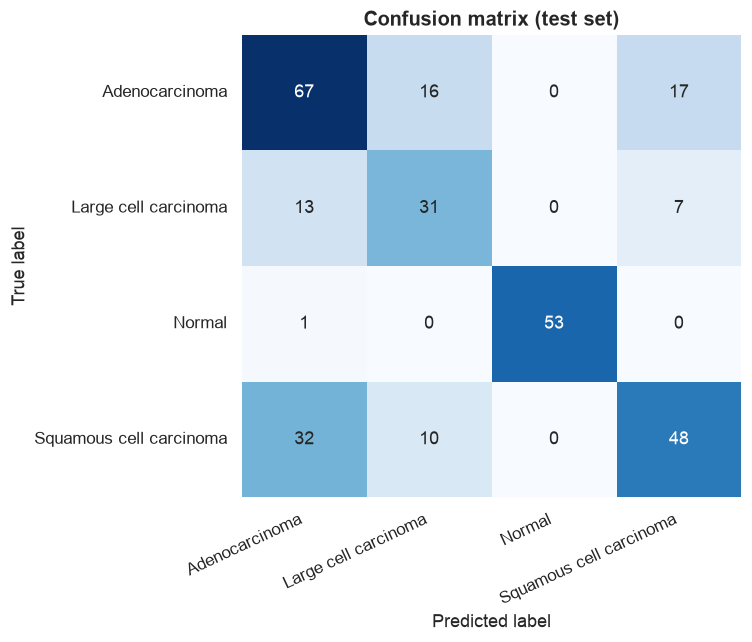

In [12]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[DISPLAY[c] for c in CLASSES],
            yticklabels=[DISPLAY[c] for c in CLASSES], cbar=False)
plt.title("Confusion matrix (test set)", fontsize=13, weight="bold")
plt.ylabel("True label"); plt.xlabel("Predicted label")
plt.xticks(rotation=25, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); savefig("confusion_matrix.png"); plt.show()

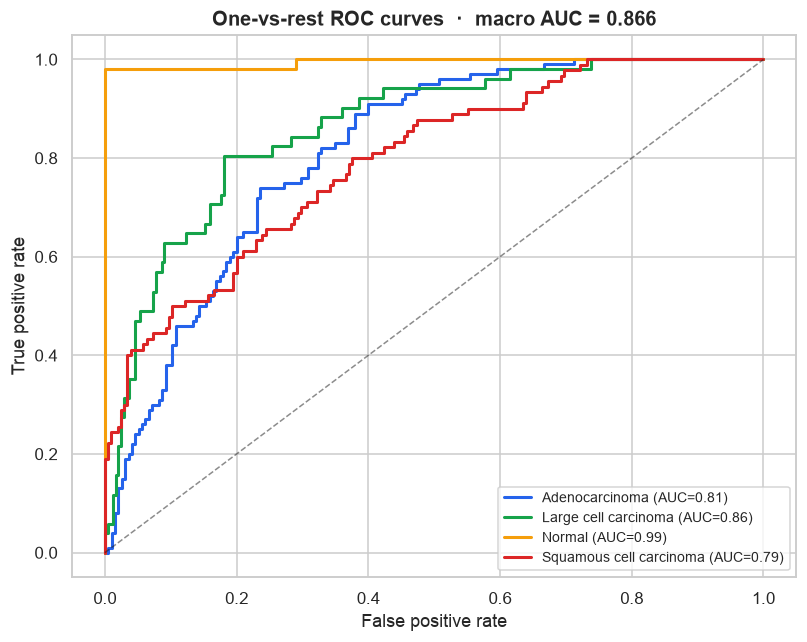

Macro AUC: 0.866


In [13]:
# One-vs-rest ROC curves + macro AUC
y_bin = label_binarize(y_true, classes=list(range(len(CLASSES))))
auc_macro = roc_auc_score(y_bin, probs, multi_class="ovr", average="macro")
per_class_auc = {}
plt.figure(figsize=(7.5, 6))
palette = ["#2563eb", "#16a34a", "#f59e0b", "#dc2626"]
for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    a = roc_auc_score(y_bin[:, i], probs[:, i])
    per_class_auc[cls] = float(a)
    plt.plot(fpr, tpr, color=palette[i], lw=2, label=f"{DISPLAY[cls]} (AUC={a:.2f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
plt.title(f"One-vs-rest ROC curves  ·  macro AUC = {auc_macro:.3f}", fontsize=13, weight="bold")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout(); savefig("roc_curves.png"); plt.show()
print(f"Macro AUC: {auc_macro:.3f}")

In [14]:
# Clinical framing: collapse to cancer (any carcinoma) vs normal
normal_idx = CLASSES.index("normal")
true_cancer = (y_true != normal_idx).astype(int)
pred_cancer = (y_pred != normal_idx).astype(int)
TP = int(((pred_cancer == 1) & (true_cancer == 1)).sum())
TN = int(((pred_cancer == 0) & (true_cancer == 0)).sum())
FP = int(((pred_cancer == 1) & (true_cancer == 0)).sum())
FN = int(((pred_cancer == 0) & (true_cancer == 1)).sum())
sensitivity = TP / (TP + FN) if (TP + FN) else 0.0   # recall on cancer
specificity = TN / (TN + FP) if (TN + FP) else 0.0   # recall on normal
binary_acc  = (TP + TN) / (TP + TN + FP + FN)
print("Cancer-vs-normal screening view:")
print(f"  Sensitivity (catch cancer) : {sensitivity:.3f}")
print(f"  Specificity (clear normal) : {specificity:.3f}")
print(f"  Binary accuracy            : {binary_acc:.3f}")
print(f"  TP={TP} TN={TN} FP={FP} FN={FN}")

Cancer-vs-normal screening view:
  Sensitivity (catch cancer) : 1.000
  Specificity (clear normal) : 0.981
  Binary accuracy            : 0.997
  TP=241 TN=53 FP=1 FN=0


### Sample predictions

A gallery of test images with the model's predicted label and confidence. Correct predictions
are framed in green, mistakes in red — useful for spotting where the model struggles.

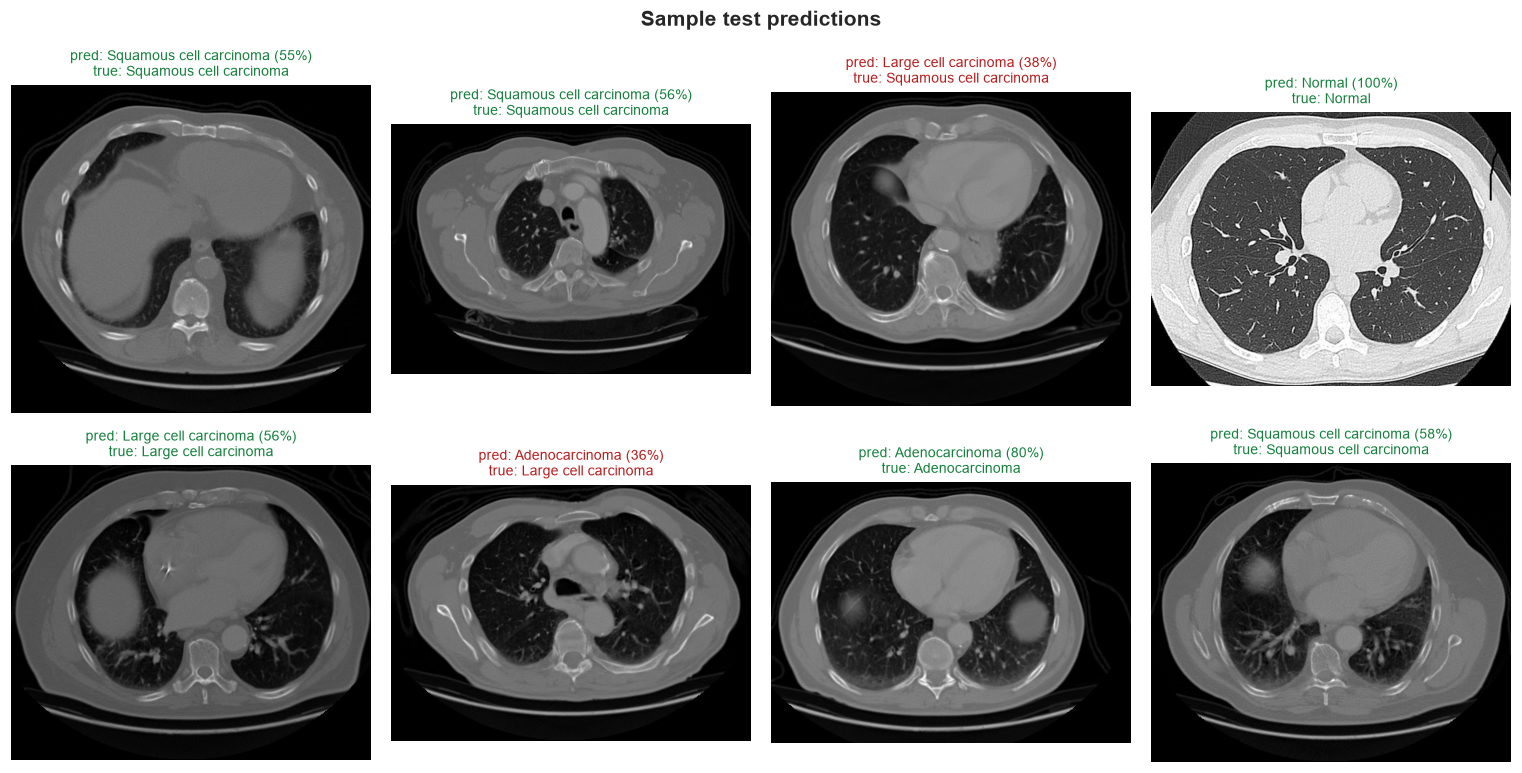

In [15]:
rng = np.random.default_rng(SEED)
idxs = rng.choice(len(test_samples), size=8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
for ax, idx in zip(axes.ravel(), idxs):
    path, true_lbl = test_samples[idx]
    ax.imshow(Image.open(path).convert("RGB")); ax.axis("off")
    pred = int(y_pred[idx]); conf = float(probs[idx, pred])
    ok = pred == true_lbl
    ax.set_title(f"pred: {DISPLAY[CLASSES[pred]]} ({conf:.0%})\ntrue: {DISPLAY[CLASSES[true_lbl]]}",
                 fontsize=9, color="#15803d" if ok else "#b91c1c")
    for s in ax.spines.values():
        s.set_visible(True); s.set_edgecolor("#15803d" if ok else "#b91c1c"); s.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Sample test predictions", fontsize=14, weight="bold")
plt.tight_layout(); savefig("sample_predictions.png"); plt.show()

## 9. Explainability — Grad-CAM

A model can be right for the wrong reasons. **Grad-CAM** highlights the regions of the CT slice
that most influenced the prediction, by weighting the last convolutional feature maps with the
gradients of the predicted class. Warmer colors = more influential.

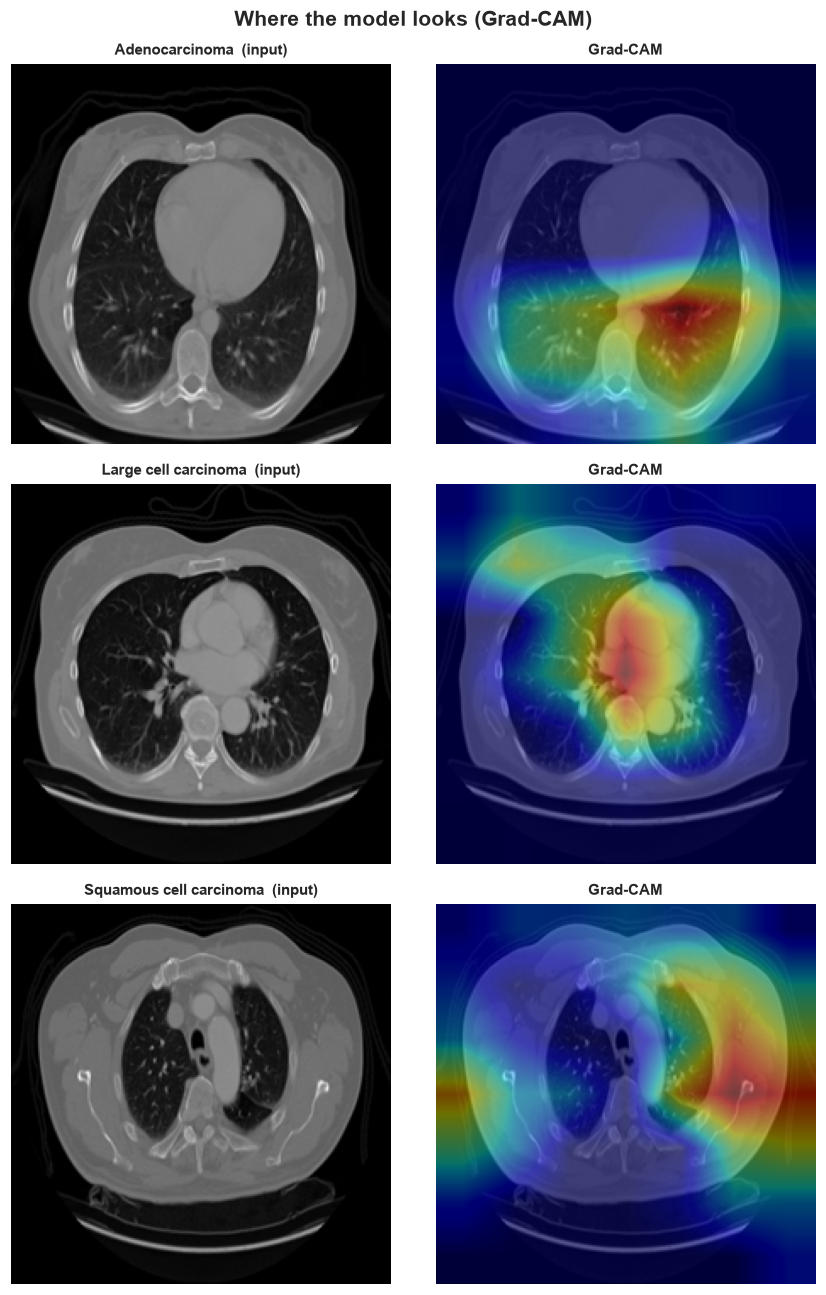

In [16]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.acts = None; self.grads = None
        target_layer.register_forward_hook(self._fwd)
        target_layer.register_full_backward_hook(self._bwd)
    def _fwd(self, m, i, o):  self.acts = o.detach()
    def _bwd(self, m, gi, go): self.grads = go[0].detach()
    def __call__(self, x, class_idx):
        x = x.clone().detach().requires_grad_(True)   # let grads flow through the frozen backbone
        self.model.zero_grad()
        with torch.enable_grad():
            out = self.model(x)
            out[0, class_idx].backward()
        weights = self.grads.mean(dim=(2, 3), keepdim=True)        # GAP over spatial dims
        cam = F.relu((weights * self.acts).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        cam = cam[0, 0].cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def render_gradcam():
    cam_engine = GradCAM(model, model.features[-1])
    # Pick one correctly-classified cancer example per cancer class for a clear visual.
    picks = []
    for cls in CANCER_CLASSES:
        ci = CLASSES.index(cls)
        for idx in range(len(test_samples)):
            if test_samples[idx][1] == ci and y_pred[idx] == ci:
                picks.append(idx); break
    if not picks:
        raise RuntimeError("no correctly-classified cancer examples to visualize")
    fig, axes = plt.subplots(len(picks), 2, figsize=(8, 4 * len(picks)))
    if len(picks) == 1: axes = axes[None, :]
    for row, idx in enumerate(picks):
        path, true_lbl = test_samples[idx]
        img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        x = eval_tf(Image.open(path).convert("RGB")).unsqueeze(0).to(DEVICE)
        cam = cam_engine(x, int(y_pred[idx]))
        axes[row, 0].imshow(img); axes[row, 0].axis("off")
        axes[row, 0].set_title(f"{DISPLAY[CLASSES[true_lbl]]}  (input)", fontsize=10, weight="bold")
        axes[row, 1].imshow(img); axes[row, 1].imshow(cam, cmap="jet", alpha=0.45)
        axes[row, 1].axis("off"); axes[row, 1].set_title("Grad-CAM", fontsize=10, weight="bold")
    fig.suptitle("Where the model looks (Grad-CAM)", fontsize=14, weight="bold")
    plt.tight_layout(); savefig("gradcam.png"); plt.show()

# Grad-CAM is a nice-to-have visualization; never let it block the ONNX export below.
try:
    render_gradcam()
except Exception as e:
    print("Grad-CAM step skipped:", repr(e))
    plt.figure(figsize=(8, 3))
    plt.text(0.5, 0.5, "Grad-CAM unavailable for this run", ha="center", va="center", fontsize=12)
    plt.axis("off"); savefig("gradcam.png"); plt.show()

## 10. Export to ONNX for the in-browser demo

To run the model **client-side in a web browser** (no server, no cloud, $0), we export it to
the open **ONNX** format. We then reload it with ONNX Runtime and verify the outputs match the
PyTorch model — a parity check that keeps the web demo honest.

In [17]:
import onnx, onnxruntime as ort

model_cpu = build_model()
model_cpu.load_state_dict(best_state)
model_cpu.eval()

onnx_path = MODELS_DIR / "model.onnx"
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
torch.onnx.export(
    model_cpu, dummy, str(onnx_path),
    input_names=["input"], output_names=["logits"],
    dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
    opset_version=13, dynamo=False,        # legacy exporter: stable, no onnxscript dependency
)
onnx.checker.check_model(onnx.load(str(onnx_path)))
print("Exported ONNX ->", onnx_path, f"({onnx_path.stat().st_size/1e6:.1f} MB)")

# Parity check: PyTorch vs ONNX Runtime on real test images
sess = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
xb = torch.stack([eval_tf(Image.open(test_samples[i][0]).convert("RGB")) for i in range(5)])
with torch.no_grad():
    torch_out = model_cpu(xb).numpy()
onnx_out = sess.run(None, {"input": xb.numpy()})[0]
print(f"Max |PyTorch - ONNX| on logits = {np.abs(torch_out - onnx_out).max():.2e}")

/var/folders/29/k6p3sm6x49b8v9z9f20vk3640000gn/T/ipykernel_55213/3423486281.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Exported ONNX -> /Users/abdulhamidnuriddinov/Documents/Projects/Video Editing with Claude/lung-cancer-detection/models/model.onnx (8.9 MB)
Max |PyTorch - ONNX| on logits = 1.65e-05


### Save artifacts for the website

We copy the ONNX model into `website/`, and write JSON files the site uses to (a) render the
results and (b) preprocess uploaded images **identically** to training.

In [18]:
import shutil
shutil.copy(onnx_path, WEB_DIR / "model.onnx")

# label + preprocessing config the JS demo reads
json.dump({
    "classes":        CLASSES,
    "display":        [DISPLAY[c] for c in CLASSES],
    "cancer_classes": CANCER_CLASSES,
}, open(WEB_DIR / "labels.json", "w"), indent=2)

json.dump({
    "size": IMG_SIZE, "mean": IMAGENET_MEAN, "std": IMAGENET_STD,
    "layout": "NCHW", "color": "RGB",
}, open(WEB_DIR / "preprocessing.json", "w"), indent=2)

# full metrics bundle for the visual report
report = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True)
metrics = {
    "generated":  time.strftime("%Y-%m-%d %H:%M"),
    "dataset":    {"name": "Chest CT-Scan images (HF: dorsar/lung-cancer)",
                    "n_train": len(train_samples), "n_valid": len(valid_samples),
                    "n_test": len(test_samples), "classes": [DISPLAY[c] for c in CLASSES]},
    "model":      {"arch": "MobileNetV2 (transfer learning)", "params": int(n_total),
                    "trainable": int(n_train), "device": str(DEVICE), "epochs": EPOCHS},
    "accuracy":   float(acc), "macro_f1": float(macro_f1), "auc_macro": float(auc_macro),
    "per_class":  {DISPLAY[c]: {"precision": report[c]["precision"], "recall": report[c]["recall"],
                                  "f1": report[c]["f1-score"], "support": int(report[c]["support"]),
                                  "auc": per_class_auc[c]} for c in CLASSES},
    "confusion_matrix": cm.tolist(),
    "binary":     {"sensitivity": sensitivity, "specificity": specificity, "accuracy": binary_acc,
                    "TP": TP, "TN": TN, "FP": FP, "FN": FN},
    "history":    history,
    "best_val_acc": float(best_val_acc),
}
json.dump(metrics, open(ASSETS_DIR / "metrics.json", "w"), indent=2)

# also as a JS global so the report renders even when opened from file:// (no fetch/CORS)
with open(ASSETS_DIR / "data.js", "w") as f:
    f.write("window.LUNG_METRICS = " + json.dumps(metrics) + ";")

print("Wrote website artifacts: model.onnx, labels.json, preprocessing.json, assets/metrics.json, assets/data.js")
print(f"\nFINAL  accuracy={acc:.3f}  macro_f1={macro_f1:.3f}  macro_auc={auc_macro:.3f}  "
      f"sensitivity={sensitivity:.3f}  specificity={specificity:.3f}")

Wrote website artifacts: model.onnx, labels.json, preprocessing.json, assets/metrics.json, assets/data.js

FINAL  accuracy=0.675  macro_f1=0.697  macro_auc=0.866  sensitivity=1.000  specificity=0.981


## 11. Results, limitations & references

**What we built.** An end-to-end pipeline that loads chest-CT slices, trains a MobileNetV2
transfer-learning classifier to distinguish three lung-cancer subtypes from normal tissue,
evaluates it with proper metrics, explains it with Grad-CAM, and exports it to run live in a
web browser. The headline numbers are printed above and saved to `website/assets/metrics.json`.

**Limitations (read honestly).**
- **Small, single-source dataset** (~767 images). Metrics are encouraging but not robust enough
  to generalize across scanners, hospitals, or populations.
- We classify **2-D slices**, not full 3-D CT volumes; real radiology reads the whole scan.
- The split sizes are small (especially validation), so individual metrics carry noise.
- **This is an educational demonstration, not a medical device.** It must not be used for
  diagnosis. Real clinical tools require large multi-center data, prospective validation, and
  regulatory clearance.
- The browser demo resizes images with the canvas API, which interpolates slightly differently
  from PIL — predictions are very close but not bit-identical to this notebook.

**References / data provenance.**
- Chest CT-Scan images dataset — Hugging Face mirror `dorsar/lung-cancer` (MIT License); originally
  distributed on Kaggle (`mohamedhanyyy`).
- MobileNetV2 — Sandler et al., *MobileNetV2: Inverted Residuals and Linear Bottlenecks*, CVPR 2018.
- Grad-CAM — Selvaraju et al., *Grad-CAM: Visual Explanations from Deep Networks*, ICCV 2017.
- Authoritative lung-cancer datasets for serious work: LIDC-IDRI / LUNA16 / NLST / NSCLC-Radiomics
  (NIH-NCI / TCIA) — see the project's `dataset.md`.

---
*Authored by **Azizbek Oqbutayev** and **Nozima Sotiboldiyeva**. Built and documented with Claude Code.*